In [1]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
"""#edge_options.add_argument('--headless')
edge_options.add_argument("--disable-images")  # Disable images
edge_options.add_argument("--disable-javascript")  # Disable JavaScript
edge_options.add_argument("--disable-plugins")  # Disable plugins
edge_options.add_argument("--disable-extensions")  # Disable extensions
edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag"""


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")

In [18]:
url="https://www.imdb.com/search/title/?title_type=feature&num_votes=1000,&role=nm0634240&credit_categories=amzn1.imdb.concept.name_credit_category.ace5cb4c-8708-4238-9542-04641e7c8171&sort=release_date,asc"
driver.get(url)

In [23]:
films=[e.get_attribute('href') for e in driver.find_elements(By.CSS_SELECTOR, 'div[class="ipc-metadata-list-summary-item__tc"] a[class="ipc-title-link-wrapper"]')]

In [27]:
urls=[str(e).split('/?')[0]+'/ratings/?ref_=tt_ov_rat' for e in films]

In [31]:
all_data=[]

for i, url in enumerate(urls, start=1):
    driver.get(url)
    html=driver.page_source
    soup=BeautifulSoup(html)
    ratings=[e.get('aria-label')  for e in soup.select('g path') if e.get('aria-label')]
    title=soup.select_one('h2[data-testid="subtitle"]').text
    
    data_dict={'Title':title, 'Ratings':ratings}
    all_data.append(data_dict)

    print(f'{i}/{len(urls)}',end='\r')


13/13

In [63]:
df=pd.DataFrame(all_data)

In [64]:
def parse_ratings(rating_list):
    result = {}
    for item in rating_list:
        score, rest = item.split(' - ')
        pct_str = rest.split('%')[0]
        result[score] = float(pct_str)
    return result

ratings_df = df['Ratings'].apply(parse_ratings).apply(pd.Series)
ratings_df = ratings_df[[str(i) for i in range(10, 0, -1)]]
df = pd.concat([df, ratings_df], axis=1)

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [67]:
matrix=df.drop(columns='Ratings')

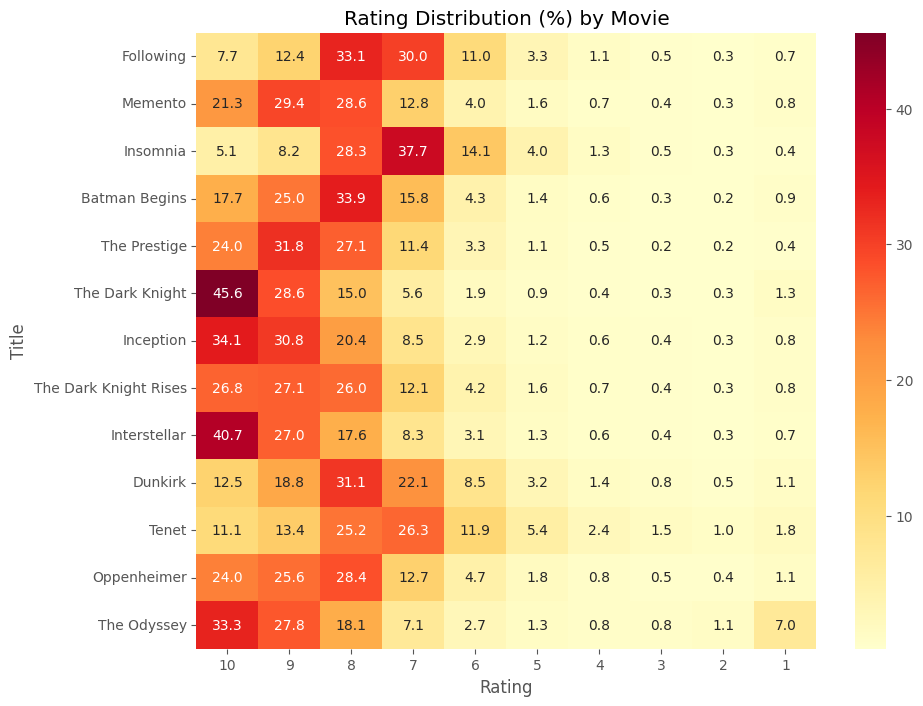

In [69]:
numeric_matrix = matrix.set_index('Title')[[str(i) for i in range(10, 0, -1)]]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_matrix, annot=True, fmt='.1f', cmap='YlOrRd')
plt.xlabel('Rating')
plt.ylabel('Title')
plt.title('Rating Distribution (%) by Movie')
plt.show()

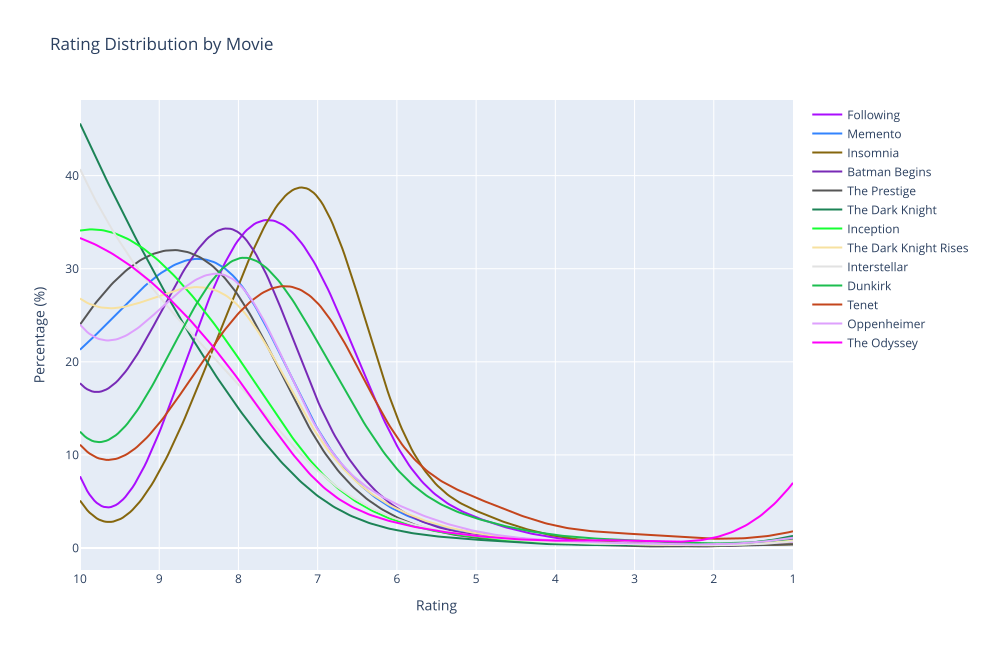

In [76]:
import plotly.graph_objects as go
from scipy.interpolate import make_interp_spline
import numpy as np
import plotly.express as px

numeric_matrix = matrix.set_index('Title')[[str(i) for i in range(10, 0, -1)]]

x = np.arange(len(numeric_matrix.columns))
x_smooth = np.linspace(x.min(), x.max(), 300)

colors = px.colors.qualitative.Alphabet

fig = go.Figure()

for i, title in enumerate(numeric_matrix.index):
    y = numeric_matrix.loc[title].values
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)
    fig.add_trace(go.Scatter(
        x=x_smooth,
        y=y_smooth,
        mode='lines',
        name=title,
        line=dict(color=colors[i % len(colors)])
    ))

fig.update_layout(
    title='Rating Distribution by Movie',
    xaxis=dict(
        title='Rating',
        tickmode='array',
        tickvals=x,
        ticktext=numeric_matrix.columns
    ),
    yaxis_title='Percentage (%)',
    width=1000,
    height=650
)

fig.show('svg')